In [1]:
from pathlib import Path

import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader

# Projekt-Root robust finden: vom aktuellen Verzeichnis aufwärts gehen, bis
# pyproject.toml gefunden wird. Funktioniert unabhängig davon, ob Jupyter aus
# dem Projekt-Root oder aus notebooks/ gestartet wurde.
def find_project_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / "pyproject.toml").exists():
            return parent
    raise FileNotFoundError("pyproject.toml nicht gefunden — Projekt-Root unklar.")

PROJECT_ROOT = find_project_root(Path.cwd())
BASE_SPLIT_DIR = PROJECT_ROOT / "data_splits"

train_df = pd.read_csv(BASE_SPLIT_DIR / "train.csv")
val_df = pd.read_csv(BASE_SPLIT_DIR / "val.csv")
test_df = pd.read_csv(BASE_SPLIT_DIR / "test.csv")

print("📂 Projekt-Root:", PROJECT_ROOT)
print("📘 Train:", len(train_df))
print("📙 Validation:", len(val_df))
print("📕 Test:", len(test_df))

📂 Projekt-Root: /Users/david/GitHub/bird-classifier
📘 Train: 5356
📙 Validation: 1407
📕 Test: 837


In [2]:
# %%
def audio_to_mel(path):

    TARGET_FRAMES = 313

    y, sr = librosa.load(
        path,
        sr=32000
    )

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=128,
        fmax=16000
    )

    mel_db = librosa.power_to_db(
        mel,
        ref=np.max
    )

    # ==================================
    # FIXED WIDTH
    # ==================================

    current_frames = mel_db.shape[1]

    # ----------------------------------
    # TOO SHORT -> PAD
    # ----------------------------------

    if current_frames < TARGET_FRAMES:

        pad_width = (
            TARGET_FRAMES -
            current_frames
        )

        mel_db = np.pad(
            mel_db,
            pad_width=((0, 0), (0, pad_width)),
            mode="constant"
        )

    # ----------------------------------
    # TOO LONG -> CUT
    # ----------------------------------

    elif current_frames > TARGET_FRAMES:

        mel_db = mel_db[:, :TARGET_FRAMES]

    # ==================================
    # NORMALIZATION (zero mean, unit std)
    # ==================================

    mel_db = (
        mel_db - mel_db.mean()
    ) / (mel_db.std() + 1e-6)

    return mel_db


print("✅ [V2] audio_to_mel geladen — MIT Normalisierung (mean=0, std=1)")

✅ [V2] audio_to_mel geladen — MIT Normalisierung (mean=0, std=1)


In [ ]:
# %%
def dataframe_to_dataset(df):

    X = []
    y = []

    for _, row in df.iterrows():

        mel = audio_to_mel(row["path"])


        X.append(mel)

        y.append(row["label"])

    X = np.array(X)
    y = np.array(y)

    # CNN Channel Dimension
    X = X[:, np.newaxis, :, :]

    return X, y

In [4]:
# %%
print("🎵 Lade Train Set...")
X_train, y_train = dataframe_to_dataset(train_df)

print("🎵 Lade Validation Set...")
X_val, y_val = dataframe_to_dataset(val_df)

print("🎵 Lade Test Set...")
X_test, y_test = dataframe_to_dataset(test_df)

print("\n✅ Shapes")

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

🎵 Lade Train Set...
🎵 Lade Validation Set...
🎵 Lade Test Set...

✅ Shapes
Train: (8760, 1, 128, 313)
Validation: (1783, 1, 128, 313)
Test: (2086, 1, 128, 313)


In [5]:
# %%
print(X_train[0].shape)
print(y_train[0])

(1, 128, 313)
1


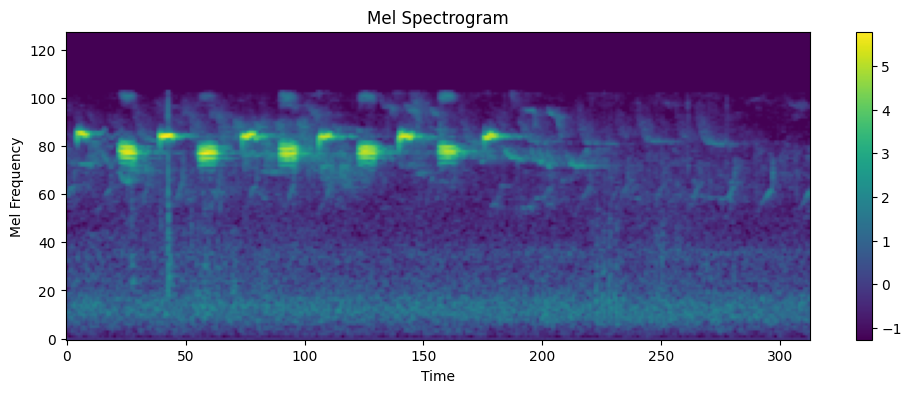

In [6]:
# %%
plt.figure(figsize=(12, 4))

plt.imshow(
    X_train[0][0],
    origin="lower",
    aspect="auto"
)

plt.colorbar()

plt.title("Mel Spectrogram")

plt.xlabel("Time")
plt.ylabel("Mel Frequency")

plt.show()

In [7]:
# %%
X_train = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_val = torch.tensor(
    X_val,
    dtype=torch.float32
)

X_test = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_train = torch.tensor(
    y_train,
    dtype=torch.long
)

y_val = torch.tensor(
    y_val,
    dtype=torch.long
)

y_test = torch.tensor(
    y_test,
    dtype=torch.long
)

print(X_train.shape)
print(y_train.shape)

torch.Size([8760, 1, 128, 313])
torch.Size([8760])


In [8]:
# %%
train_dataset = TensorDataset(
    X_train,
    y_train
)

val_dataset = TensorDataset(
    X_val,
    y_val
)

test_dataset = TensorDataset(
    X_test,
    y_test
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("📘 Train batches:", len(train_loader))
print("📙 Validation batches:", len(val_loader))
print("📕 Test batches:", len(test_loader))

📘 Train batches: 274
📙 Validation batches: 56
📕 Test batches: 66


In [9]:
# %%
# ======================================
# SPEC AUGMENT (Frequenz- / Zeit-Masking)
# ======================================

class SpecAugment(nn.Module):

    def __init__(
        self,
        freq_mask=24,
        time_mask=40,
        n_freq_masks=2,
        n_time_masks=2
    ):
        super().__init__()
        self.freq_mask = freq_mask
        self.time_mask = time_mask
        self.n_freq_masks = n_freq_masks
        self.n_time_masks = n_time_masks

    def forward(self, x):

        # x: (B, 1, F, T)
        B, C, F, T = x.shape
        x = x.clone()

        for _ in range(self.n_freq_masks):
            f = torch.randint(0, self.freq_mask + 1, (1,)).item()
            if f > 0:
                f0 = torch.randint(0, max(1, F - f), (1,)).item()
                x[:, :, f0:f0 + f, :] = 0

        for _ in range(self.n_time_masks):
            t = torch.randint(0, self.time_mask + 1, (1,)).item()
            if t > 0:
                t0 = torch.randint(0, max(1, T - t), (1,)).item()
                x[:, :, :, t0:t0 + t] = 0

        return x


# ======================================
# BIRD CNN (V3 — tiefer + augmentiert)
# ======================================

class BirdCNN(nn.Module):

    def __init__(self, num_classes=4, dropout=0.5):

        super().__init__()

        # ----- Augmentation (nur im Training aktiv) -----
        self.spec_aug = SpecAugment(
            freq_mask=24,
            time_mask=40,
            n_freq_masks=2,
            n_time_masks=2
        )

        # ----- Conv-Block: 2x (Conv-BN-ReLU) + MaxPool -----
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )

        self.features = nn.Sequential(
            conv_block(1, 32),
            conv_block(32, 64),
            conv_block(64, 128),
            conv_block(128, 256),
        )

        # ----- Global Average Pooling -----
        self.pool = nn.AdaptiveAvgPool2d(1)

        # ----- Classifier -----
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

        print(
            f"📐 [V3] BirdCNN gebaut — 4 Conv-Blöcke (32→64→128→256), "
            f"GAP + Dropout({dropout}) + Linear(256, {num_classes})"
        )

    def forward(self, x):
        if self.training:
            x = self.spec_aug(x)
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x


print("✅ [V3] BirdCNN-Klasse definiert — tiefer + SpecAugment")

✅ [V3] BirdCNN-Klasse definiert — tiefer + SpecAugment


In [10]:
# %%
device = torch.device(
    "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

model = BirdCNN().to(device)

print(device)

📐 [V3] BirdCNN gebaut — 4 Conv-Blöcke (32→64→128→256), GAP + Dropout(0.5) + Linear(256, 4)
mps


In [11]:
# %%
# ======================================
# LOSS, OPTIMIZER, SCHEDULER
# ======================================

NUM_EPOCHS = 20

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS
)

print(
    f"✅ [V3] Optimizer = AdamW (lr=1e-3, wd=1e-4), "
    f"Scheduler = CosineAnnealingLR (T_max={NUM_EPOCHS}), "
    f"Loss = CrossEntropy(label_smoothing=0.1)"
)

✅ [V3] Optimizer = AdamW (lr=1e-3, wd=1e-4), Scheduler = CosineAnnealingLR (T_max=20), Loss = CrossEntropy(label_smoothing=0.1)


In [12]:
print(model)

BirdCNN(
  (spec_aug): SpecAugment()
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, 

In [13]:
# %%
# ======================================
# TRAINING LOOP (mit Best-Model-Checkpoint)
# ======================================

BEST_PATH = "model_best.pth"

best_val_acc = 0.0
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

for epoch in range(1, NUM_EPOCHS + 1):

    # -------- TRAIN --------
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        train_correct += (predicted == labels).sum().item()
        train_total += labels.size(0)

    # -------- VALIDATION --------
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    train_loss /= train_total
    val_loss /= val_total
    train_acc = 100 * train_correct / train_total
    val_acc = 100 * val_correct / val_total

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    scheduler.step()

    marker = ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), BEST_PATH)
        marker = " 💾 (best)"

    lr_now = optimizer.param_groups[0]["lr"]
    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"lr {lr_now:.2e} | "
        f"train loss {train_loss:.4f} acc {train_acc:5.2f}% | "
        f"val loss {val_loss:.4f} acc {val_acc:5.2f}%{marker}"
    )

print(f"\n🏆 Best Val Accuracy: {best_val_acc:.2f}%  → {BEST_PATH}")

Epoch 01/20 | lr 9.94e-04 | train loss 0.9436 acc 68.74% | val loss 0.9121 acc 69.94% 💾 (best)
Epoch 02/20 | lr 9.76e-04 | train loss 0.7358 acc 81.61% | val loss 0.6667 acc 87.32% 💾 (best)
Epoch 03/20 | lr 9.46e-04 | train loss 0.6830 acc 84.66% | val loss 0.8874 acc 74.03%
Epoch 04/20 | lr 9.05e-04 | train loss 0.6578 acc 85.79% | val loss 0.9953 acc 68.03%
Epoch 05/20 | lr 8.54e-04 | train loss 0.6422 acc 86.82% | val loss 1.3062 acc 63.71%
Epoch 06/20 | lr 7.94e-04 | train loss 0.6160 acc 87.89% | val loss 0.9201 acc 86.09%
Epoch 07/20 | lr 7.27e-04 | train loss 0.6056 acc 89.18% | val loss 0.7045 acc 85.70%
Epoch 08/20 | lr 6.55e-04 | train loss 0.5885 acc 89.90% | val loss 0.6698 acc 86.37%
Epoch 09/20 | lr 5.78e-04 | train loss 0.5783 acc 90.23% | val loss 0.7738 acc 84.80%
Epoch 10/20 | lr 5.00e-04 | train loss 0.5671 acc 91.02% | val loss 0.7027 acc 83.96%
Epoch 11/20 | lr 4.22e-04 | train loss 0.5518 acc 91.77% | val loss 0.6650 acc 86.26%
Epoch 12/20 | lr 3.45e-04 | train lo

In [14]:
# %%
# ======================================
# TEST EVALUATION (Best Model)
# ======================================

model.load_state_dict(
    torch.load(BEST_PATH, map_location=device)
)
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        all_preds.append(predicted.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

test_accuracy = 100 * (all_preds == all_labels).mean()
print(f"\n📕 Test Accuracy: {test_accuracy:.2f}%\n")

# ----- Per-Class-Accuracy -----
label_to_name = (
    train_df
    .drop_duplicates("label")
    .set_index("label")["class_name"]
    .to_dict()
)

print("📊 Per-Class-Accuracy:")
for c in sorted(label_to_name.keys()):
    mask = all_labels == c
    n = int(mask.sum())
    if n > 0:
        acc = 100 * (all_preds[mask] == all_labels[mask]).mean()
        print(f"  {label_to_name[c]:<15} ({n:4d} samples): {acc:5.2f}%")

# ----- Confusion Matrix -----
try:
    from sklearn.metrics import confusion_matrix, classification_report

    names = [label_to_name[c] for c in sorted(label_to_name.keys())]
    cm = confusion_matrix(all_labels, all_preds)

    print("\n🔢 Confusion Matrix (rows = true, cols = pred):")
    header = "          " + "  ".join(f"{n[:8]:>8}" for n in names)
    print(header)
    for i, n in enumerate(names):
        row = "  ".join(f"{v:>8d}" for v in cm[i])
        print(f"{n[:8]:>8}  {row}")

    print("\n📋 Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=names, digits=3))
except ImportError:
    print("\n(sklearn nicht installiert — Confusion Matrix übersprungen)")


📕 Test Accuracy: 87.87%

📊 Per-Class-Accuracy:
  Amsel           ( 580 samples): 93.62%
  Kohlmeise       ( 673 samples): 86.63%
  Rotkehlchen     ( 327 samples): 88.38%
  Background      ( 506 samples): 82.61%

🔢 Confusion Matrix (rows = true, cols = pred):
             Amsel  Kohlmeis  Rotkehlc  Backgrou
   Amsel       543         0        10        27
Kohlmeis         6       583        63        21
Rotkehlc         1        16       289        21
Backgrou        22        33        33       418

📋 Classification Report:
              precision    recall  f1-score   support

       Amsel      0.949     0.936     0.943       580
   Kohlmeise      0.922     0.866     0.893       673
 Rotkehlchen      0.732     0.884     0.801       327
  Background      0.858     0.826     0.842       506

    accuracy                          0.879      2086
   macro avg      0.865     0.878     0.870      2086
weighted avg      0.884     0.879     0.880      2086



## 📊 Modell-Auswertung

Detaillierte Analyse der Modell-Performance auf dem Test-Set:

1. **Trainingsverlauf** — Loss/Accuracy je Epoche (Overfitting-Check)
2. **Vorhersagen sammeln** — Softmax-Wahrscheinlichkeiten (Basis der Auswertung)
3. **Confusion Matrix** — absolut + zeilennormiert (welche Klassen verwechselt werden)
4. **Per-Class Precision/Recall/F1** — Stärken/Schwächen je Vogelart
5. **Konfidenz & Kalibrierung** — sind die Wahrscheinlichkeiten "ehrlich"? (ECE)
6. **ROC- & PR-Kurven** — Trennschärfe je Klasse (One-vs-Rest)
7. **Fehlklassifikationen** — die sichersten Fehler als Spektrogramme

In [ ]:
# ======================================
# 1) Trainingsverlauf — Loss & Accuracy je Epoche
#    Zeigt Overfitting (train steigt, val stagniert/fällt) und wann das
#    beste Modell gespeichert wurde.
# ======================================
epochs = range(1, len(history["train_loss"]) + 1)
best_epoch = int(np.argmax(history["val_acc"])) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history["train_loss"], "o-", label="Train")
axes[0].plot(epochs, history["val_loss"], "o-", label="Validation")
axes[0].set_xlabel("Epoche")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss-Verlauf")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history["train_acc"], "o-", label="Train")
axes[1].plot(epochs, history["val_acc"], "o-", label="Validation")
axes[1].axvline(best_epoch, color="green", ls="--", alpha=0.7,
                label=f"Best (Epoche {best_epoch})")
axes[1].set_xlabel("Epoche")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Accuracy-Verlauf")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"🏆 Beste Val-Accuracy {max(history['val_acc']):.2f}% in Epoche {best_epoch} "
      f"(von {len(epochs)} Epochen)")

In [ ]:
# ======================================
# 2) Vorhersagen + Softmax-Wahrscheinlichkeiten auf dem Test-Set sammeln
#    (Grundlage für alle folgenden Auswertungen)
#    Nutzt das oben bereits geladene Best-Modell.
# ======================================
import torch.nn.functional as F

label_to_name = (
    train_df.drop_duplicates("label").set_index("label")["class_name"].to_dict()
)
class_names = [label_to_name[i] for i in sorted(label_to_name)]

model.eval()
prob_batches, label_batches = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        logits = model(inputs)
        prob_batches.append(F.softmax(logits, dim=1).cpu().numpy())
        label_batches.append(labels.numpy())

probs = np.concatenate(prob_batches)   # (N, C) Wahrscheinlichkeiten
y_true = np.concatenate(label_batches)  # (N,)  wahre Labels
y_pred = probs.argmax(axis=1)           # (N,)  Vorhersagen
conf = probs.max(axis=1)                # (N,)  Konfidenz der Vorhersage

print(f"Gesammelt: {len(y_true)} Test-Clips, {len(class_names)} Klassen {class_names}")
print(f"Test-Accuracy: {100 * (y_pred == y_true).mean():.2f}%")

In [ ]:
# ======================================
# 3) Confusion Matrix als Heatmap (absolut + zeilennormiert = Recall)
# ======================================
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, mat, title, fmt in [
    (axes[0], cm, "Absolut", "d"),
    (axes[1], cm_norm, "Zeilennormiert (Recall)", ".2f"),
]:
    im = ax.imshow(mat, cmap="Blues", vmin=0, vmax=mat.max())
    ax.set_xticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticks(range(len(class_names)))
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Vorhergesagt")
    ax.set_ylabel("Wahr")
    ax.set_title(f"Confusion Matrix — {title}")
    thresh = mat.max() * 0.6
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(
                j, i, format(mat[i, j], fmt),
                ha="center", va="center",
                color="white" if mat[i, j] > thresh else "black",
                fontsize=9,
            )
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [ ]:
# ======================================
# 4) Per-Class Precision / Recall / F1
# ======================================
from sklearn.metrics import precision_recall_fscore_support

p, r, f1, support = precision_recall_fscore_support(
    y_true, y_pred, labels=list(range(len(class_names))), zero_division=0
)

x = np.arange(len(class_names))
w = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w, p, w, label="Precision")
ax.bar(x, r, w, label="Recall")
ax.bar(x + w, f1, w, label="F1")

for i in range(len(class_names)):
    for off, val in [(-w, p[i]), (0, r[i]), (w, f1[i])]:
        ax.text(i + off, val + 0.015, f"{val:.2f}", ha="center", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([f"{n}\n(n={s})" for n, s in zip(class_names, support)])
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score")
ax.set_title("Per-Class Precision / Recall / F1 (Test)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ======================================
# 5) Konfidenz-Verteilung & Kalibrierung
#    Zeigt, ob die Softmax-Wahrscheinlichkeiten "ehrlich" sind.
# ======================================
correct = y_pred == y_true

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Konfidenz-Histogramm: korrekt vs. falsch ---
axes[0].hist(conf[correct], bins=20, range=(0, 1), alpha=0.6, color="green", label="korrekt")
axes[0].hist(conf[~correct], bins=20, range=(0, 1), alpha=0.6, color="red", label="falsch")
axes[0].set_xlabel("Modell-Konfidenz (max. Softmax)")
axes[0].set_ylabel("Anzahl Clips")
axes[0].set_title("Konfidenz-Verteilung")
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Reliability Diagram + ECE ---
n_bins = 10
bins = np.linspace(0, 1, n_bins + 1)
bin_idx = np.clip(np.digitize(conf, bins) - 1, 0, n_bins - 1)

conf_means, acc_means, ece = [], [], 0.0
for b in range(n_bins):
    m = bin_idx == b
    if m.sum() > 0:
        c_mean = conf[m].mean()
        a_mean = correct[m].mean()
        conf_means.append(c_mean)
        acc_means.append(a_mean)
        ece += (m.sum() / len(conf)) * abs(a_mean - c_mean)

axes[1].plot([0, 1], [0, 1], "--", color="gray", label="perfekt kalibriert")
axes[1].plot(conf_means, acc_means, "o-", color="C0", label="Modell")
axes[1].set_xlabel("Mittlere Konfidenz")
axes[1].set_ylabel("Tatsächliche Accuracy")
axes[1].set_title(f"Reliability Diagram (ECE = {ece:.3f})")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Ø Konfidenz: {conf.mean():.3f}  |  Accuracy: {correct.mean():.3f}  |  ECE: {ece:.3f}")
print("(ECE nahe 0 = gut kalibriert; Konfidenz >> Accuracy = überkonfident)")

In [ ]:
# ======================================
# 6) ROC- und Precision-Recall-Kurven (One-vs-Rest je Klasse)
# ======================================
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

y_bin = label_binarize(y_true, classes=list(range(len(class_names))))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for c, name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_bin[:, c], probs[:, c])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.3f})")

    prec, rec, _ = precision_recall_curve(y_bin[:, c], probs[:, c])
    ap = average_precision_score(y_bin[:, c], probs[:, c])
    axes[1].plot(rec, prec, label=f"{name} (AP={ap:.3f})")

axes[0].plot([0, 1], [0, 1], "--", color="gray", alpha=0.6)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC-Kurven (One-vs-Rest)")
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall-Kurven (One-vs-Rest)")
axes[1].legend(loc="lower left")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ======================================
# 7) Sicherste Fehlklassifikationen
#    (hohe Konfidenz, aber falsch) als Mel-Spektrogramme
# ======================================
wrong = np.where(y_pred != y_true)[0]
wrong_sorted = wrong[np.argsort(-conf[wrong])]
n_show = min(8, len(wrong_sorted))

if n_show == 0:
    print("Keine Fehlklassifikationen 🎉")
else:
    cols = 4
    rows = int(np.ceil(n_show / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3 * rows))
    axes = np.array(axes).reshape(-1)
    for ax in axes:
        ax.axis("off")
    for k, w_idx in enumerate(wrong_sorted[:n_show]):
        mel = X_test[w_idx][0].cpu().numpy()  # bereits normalisiertes Mel
        ax = axes[k]
        ax.axis("on")
        ax.imshow(mel, origin="lower", aspect="auto", cmap="magma")
        ax.set_title(
            f"wahr: {class_names[y_true[w_idx]]}\n"
            f"pred: {class_names[y_pred[w_idx]]} ({conf[w_idx]:.2f})",
            fontsize=9,
        )
        ax.set_xticks([])
        ax.set_yticks([])
    plt.suptitle("Sicherste Fehlklassifikationen (hohe Konfidenz, aber falsch)", y=1.02)
    plt.tight_layout()
    plt.show()

    # Häufigste Verwechslungspaare
    from collections import Counter
    pairs = Counter(
        (class_names[y_true[i]], class_names[y_pred[i]]) for i in wrong
    )
    print("Top-Verwechslungen (wahr → pred):")
    for (t, p_), n in pairs.most_common(5):
        print(f"  {t:<12} → {p_:<12} : {n}x")

In [15]:
print(model)

BirdCNN(
  (spec_aug): SpecAugment()
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, 

In [16]:
# %%
torch.save(
    model.state_dict(),
    "model.pth"
)

print("💾 Modell gespeichert")

💾 Modell gespeichert
